In [ ]:
# try the same trajectory umap-already based on all of them... 

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import patchworklib as pw

import methods as mt


<Figure size 100x100 with 0 Axes>

In [2]:
adata = sc.read_h5ad("/home/roger/data_itx/adata_all.h5ad")

umap_cd4 = pd.read_csv("/home/roger/Baixades/tots_cd4_umap_coordinates.csv")
umap_cd8 = pd.read_csv("/home/roger/Baixades/totscd8_umap_coordinates.csv")


def subset_with_umap(adata, umap_df):
    umap_df = umap_df.set_index("cell")[["UMAP_1", "UMAP_2"]]

    common = adata.obs_names.intersection(umap_df.index)

    adata_sub = adata[common].copy()
    adata_sub.obsm["X_umap"] = umap_df.loc[adata_sub.obs_names].values

    print(f"Kept {adata_sub.n_obs} cells")

    return adata_sub


adata_cd4 = subset_with_umap(adata, umap_cd4)
adata_cd8 = subset_with_umap(adata, umap_cd8)

Kept 8617 cells
Kept 12968 cells


In [3]:
palette_cd8 = {
    "CD8_naive": "skyblue",
    "CD8_mem": "green",
    "CD8_ex": "red",
    "CD8_ex_act": "purple",
    "CD8_eff": "navy",
    "CD8_act": "gold",
}

palette_cd4 = {
    "Naive": "#4C72B0",
    "Tfh": "#DD8452",
    "Th17": "#55A868",
    "Treg": "#C44E52",
}


In [4]:
def build_trajectory_row(adata_subset, palette, root_celltype, start_node, row_name, label_prefix, brick_figsize=(3.8, 3.4)):
    monocle_ax = pw.Brick(f"{label_prefix}_monocle3", figsize=brick_figsize)
    paga_ax = pw.Brick(f"{label_prefix}_paga", figsize=brick_figsize)
    slingshot_ax = pw.Brick(f"{label_prefix}_slingshot", figsize=brick_figsize)

    mt.monocle3(
        adata_subset.copy(),
        palette_cd8=palette,
        ax=monocle_ax,
        title=f"{row_name} | Monocle3",
        show=False,
    )
    mt.run_paga(
        adata_subset.copy(),
        root_celltype=root_celltype,
        ax=paga_ax,
        title=f"{row_name} | PAGA",
        show=False,
    )
    mt.run_slingshot(
        adata_subset.copy(),
        start_node=start_node,
        ax=slingshot_ax,
        title=f"{row_name} | Slingshot",
        show=False,
    )

    return monocle_ax | paga_ax | slingshot_ax

In [5]:
adata_cd8_pre = adata_cd8[adata_cd8.obs['treatment'] == "pre"]
adata_cd4_pre = adata_cd4[adata_cd4.obs['treatment'] == "pre"]
adata_cd8_post = adata_cd8[adata_cd8.obs['treatment'] == "post"]
adata_cd4_post = adata_cd4[adata_cd4.obs['treatment'] == "post"]

build_trajectory_row(adata_cd8_pre, palette_cd8, root_celltype="CD8_naive", start_node=4, row_name="CD8 pre", label_prefix="cd8_pre", brick_figsize=(3.8, 3.4))


build_trajectory_row(adata_cd8_post, palette_cd8, root_celltype="CD8_naive", start_node=4, row_name="CD8 post", label_prefix="cd8_post", brick_figsize=(3.8, 3.4))


build_trajectory_row(adata_cd4_pre, palette_cd4, root_celltype="Naive", start_node=4, row_name="CD4 pre", label_prefix="cd4_pre", brick_figsize=(3.8, 3.4))


build_trajectory_row(adata_cd4_post, palette_cd4, root_celltype="Naive", start_node=4, row_name="CD4 post", label_prefix="cd4_post", brick_figsize=(3.8, 3.4))


Lineages: [Lineage[4, 1], Lineage[4, 2, 0], Lineage[4, 2, 3], Lineage[4, 5]]


  0%|          | 0/1 [00:00<?, ?it/s]

Reversing from leaf to root
Averaging branch @2 with lineages: [1, 2] [<pcurvepy2.pcurve.PrincipalCurve object at 0x7ff6b05c7390>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7ff6b05c6fd0>]
Averaging branch @4 with lineages: [0, 1, 2, 3] [<pcurvepy2.pcurve.PrincipalCurve object at 0x7ff6ab5cd400>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7ff6b0b0f100>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7ff6b0b0f820>]
Shrinking branch @4 with curves: [<pcurvepy2.pcurve.PrincipalCurve object at 0x7ff6ab5cd400>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7ff6b0b0f100>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7ff6b0b0f820>]
Shrinking branch @2 with curves: [<pcurvepy2.pcurve.PrincipalCurve object at 0x7ff6b05c7390>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7ff6b05c6fd0>]
Lineages: [Lineage[4, 1], Lineage[4, 5, 3, 0], Lineage[4, 5, 3, 2]]


  0%|          | 0/1 [00:00<?, ?it/s]

Reversing from leaf to root
Averaging branch @3 with lineages: [1, 2] [<pcurvepy2.pcurve.PrincipalCurve object at 0x7ff6b0c3e7a0>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7ff6b13f5350>]
Averaging branch @4 with lineages: [0, 1, 2] [<pcurvepy2.pcurve.PrincipalCurve object at 0x7ff6b0c3d040>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7ff727b5b150>]
Shrinking branch @4 with curves: [<pcurvepy2.pcurve.PrincipalCurve object at 0x7ff6b0c3d040>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7ff727b5b150>]
Shrinking branch @3 with curves: [<pcurvepy2.pcurve.PrincipalCurve object at 0x7ff6b0c3e7a0>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7ff6b13f5350>]
Lineages: [Lineage[1, 0, 2], Lineage[1, 3]]


  0%|          | 0/1 [00:00<?, ?it/s]

Reversing from leaf to root
Averaging branch @1 with lineages: [0, 1] [<pcurvepy2.pcurve.PrincipalCurve object at 0x7ff6aad84910>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7ff6b105caa0>]
Shrinking branch @1 with curves: [<pcurvepy2.pcurve.PrincipalCurve object at 0x7ff6aad84910>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7ff6b105caa0>]
Lineages: [Lineage[1, 0, 2], Lineage[1, 3]]


  0%|          | 0/1 [00:00<?, ?it/s]

Reversing from leaf to root
Averaging branch @1 with lineages: [0, 1] [<pcurvepy2.pcurve.PrincipalCurve object at 0x7ff6a831f710>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7ff72ad6f520>]
Shrinking branch @1 with curves: [<pcurvepy2.pcurve.PrincipalCurve object at 0x7ff6a831f710>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7ff72ad6f520>]


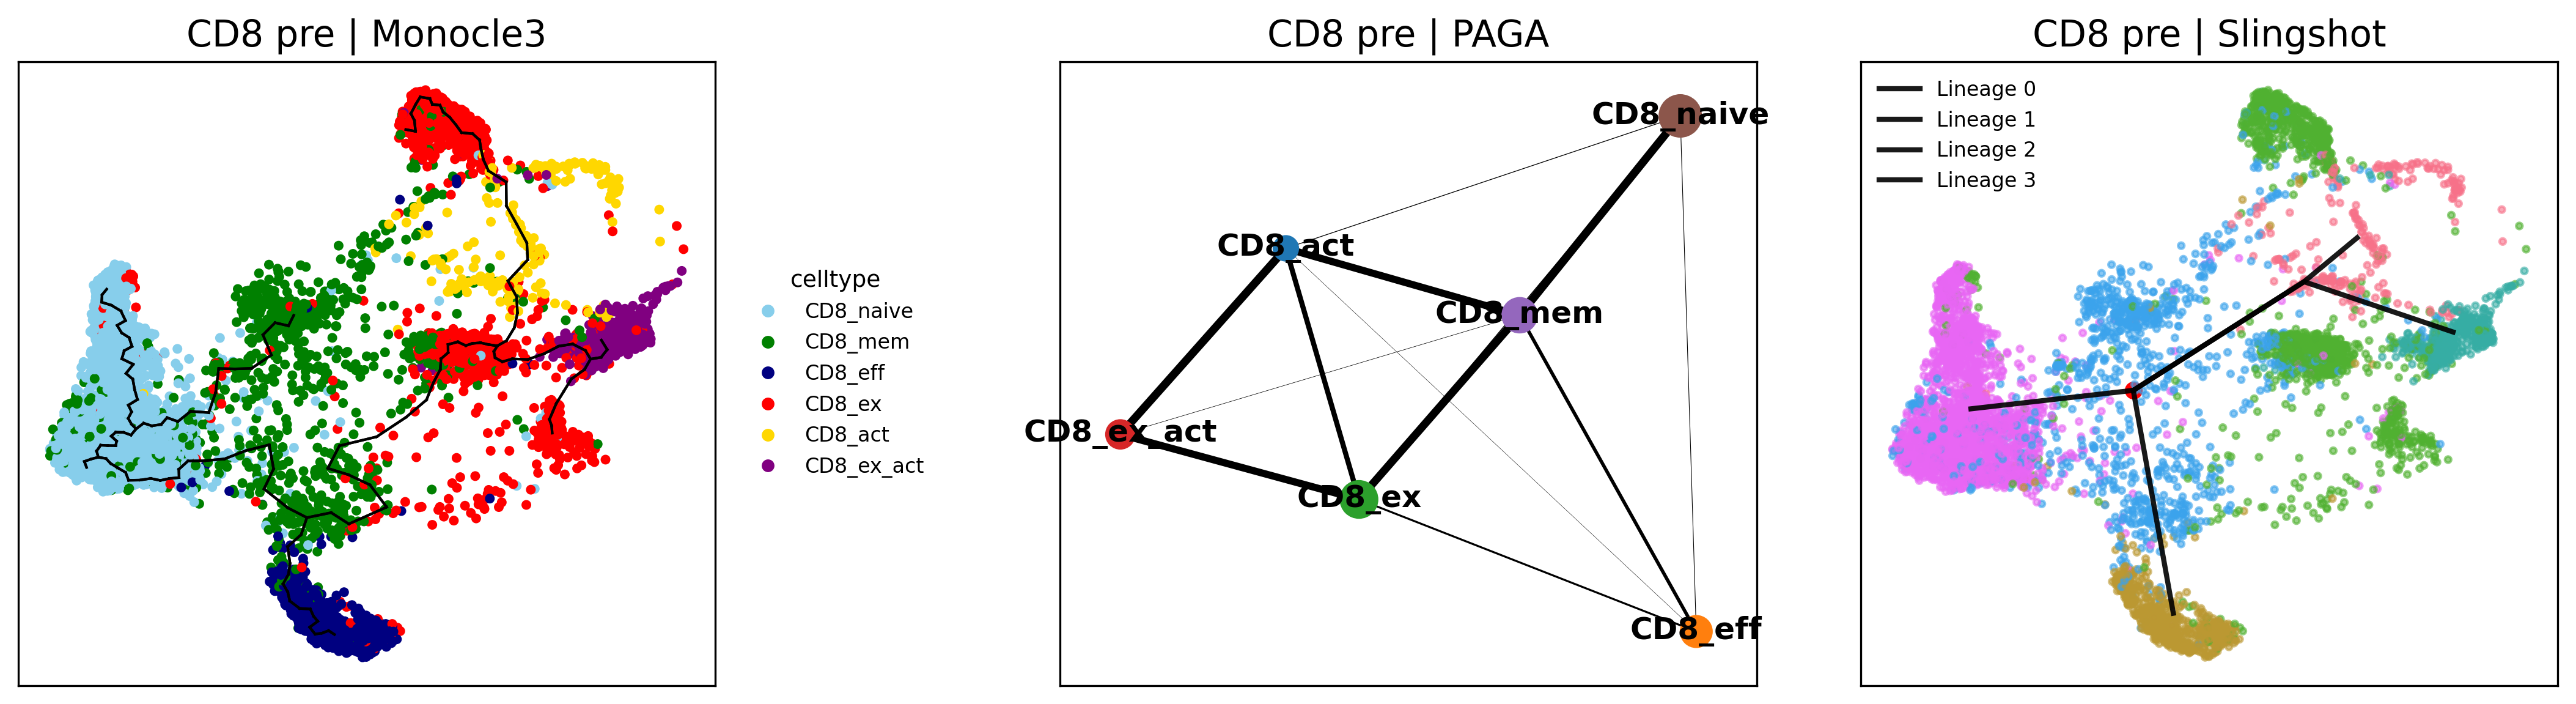

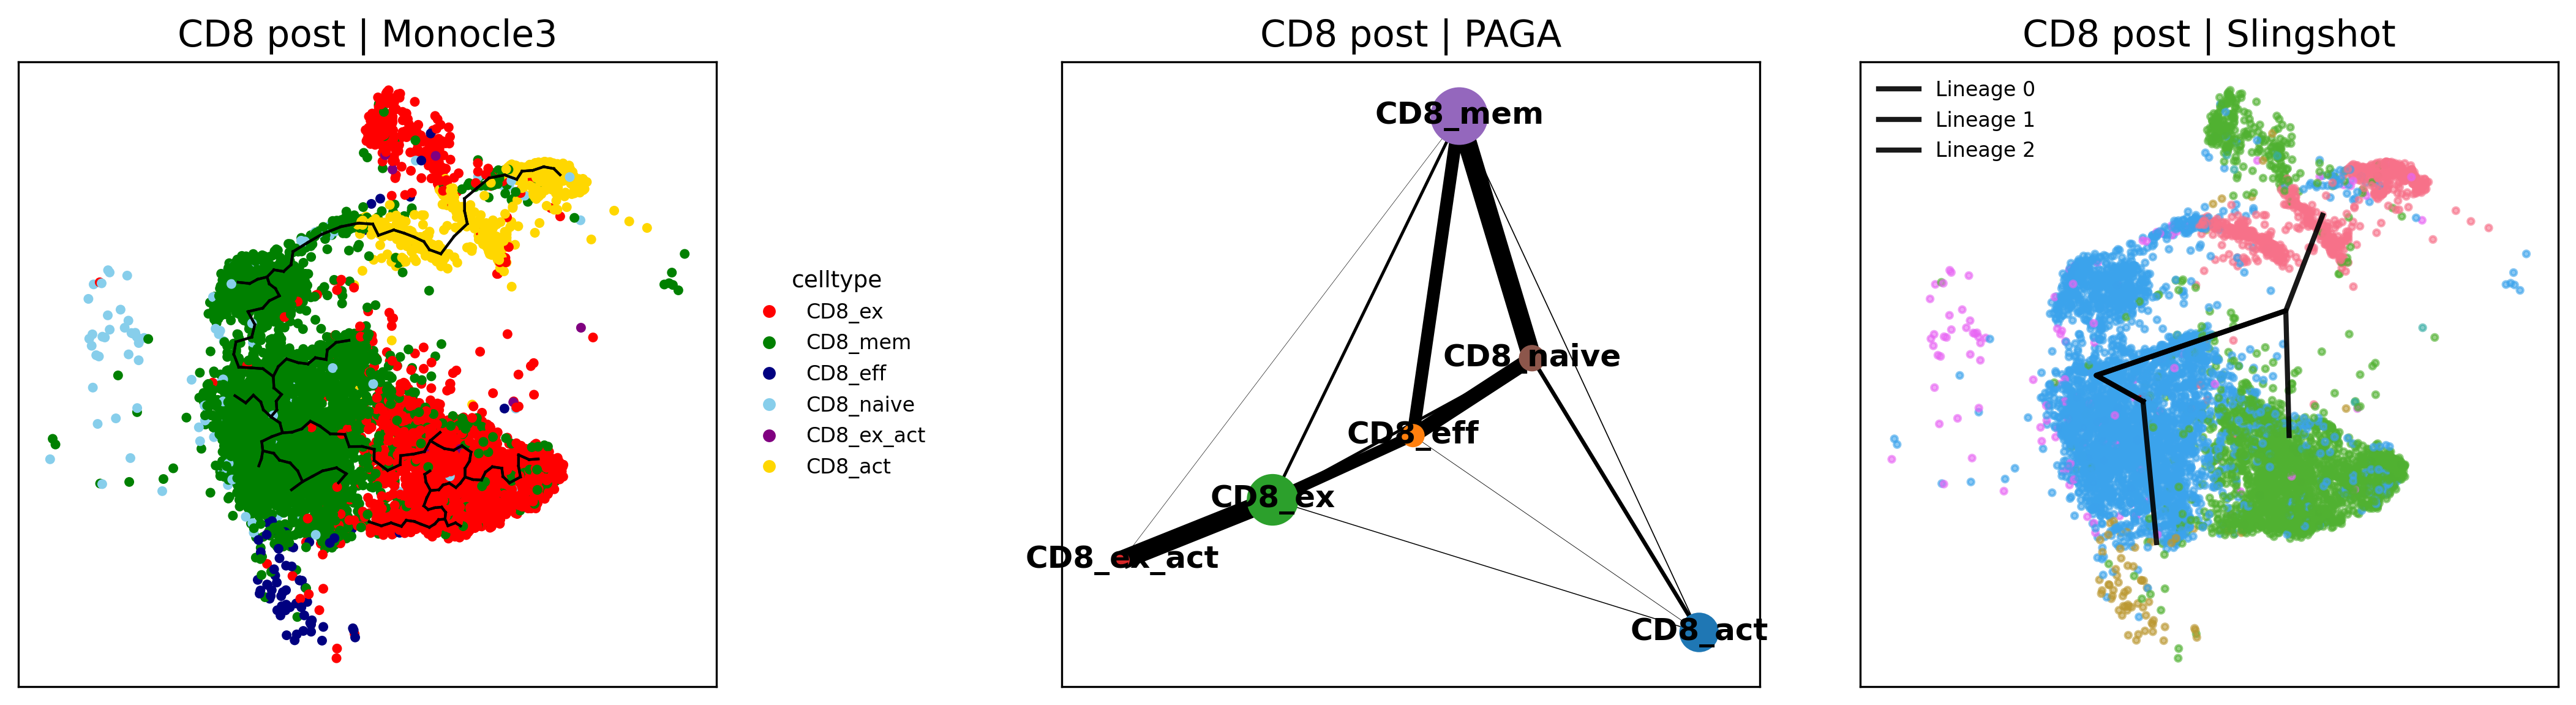

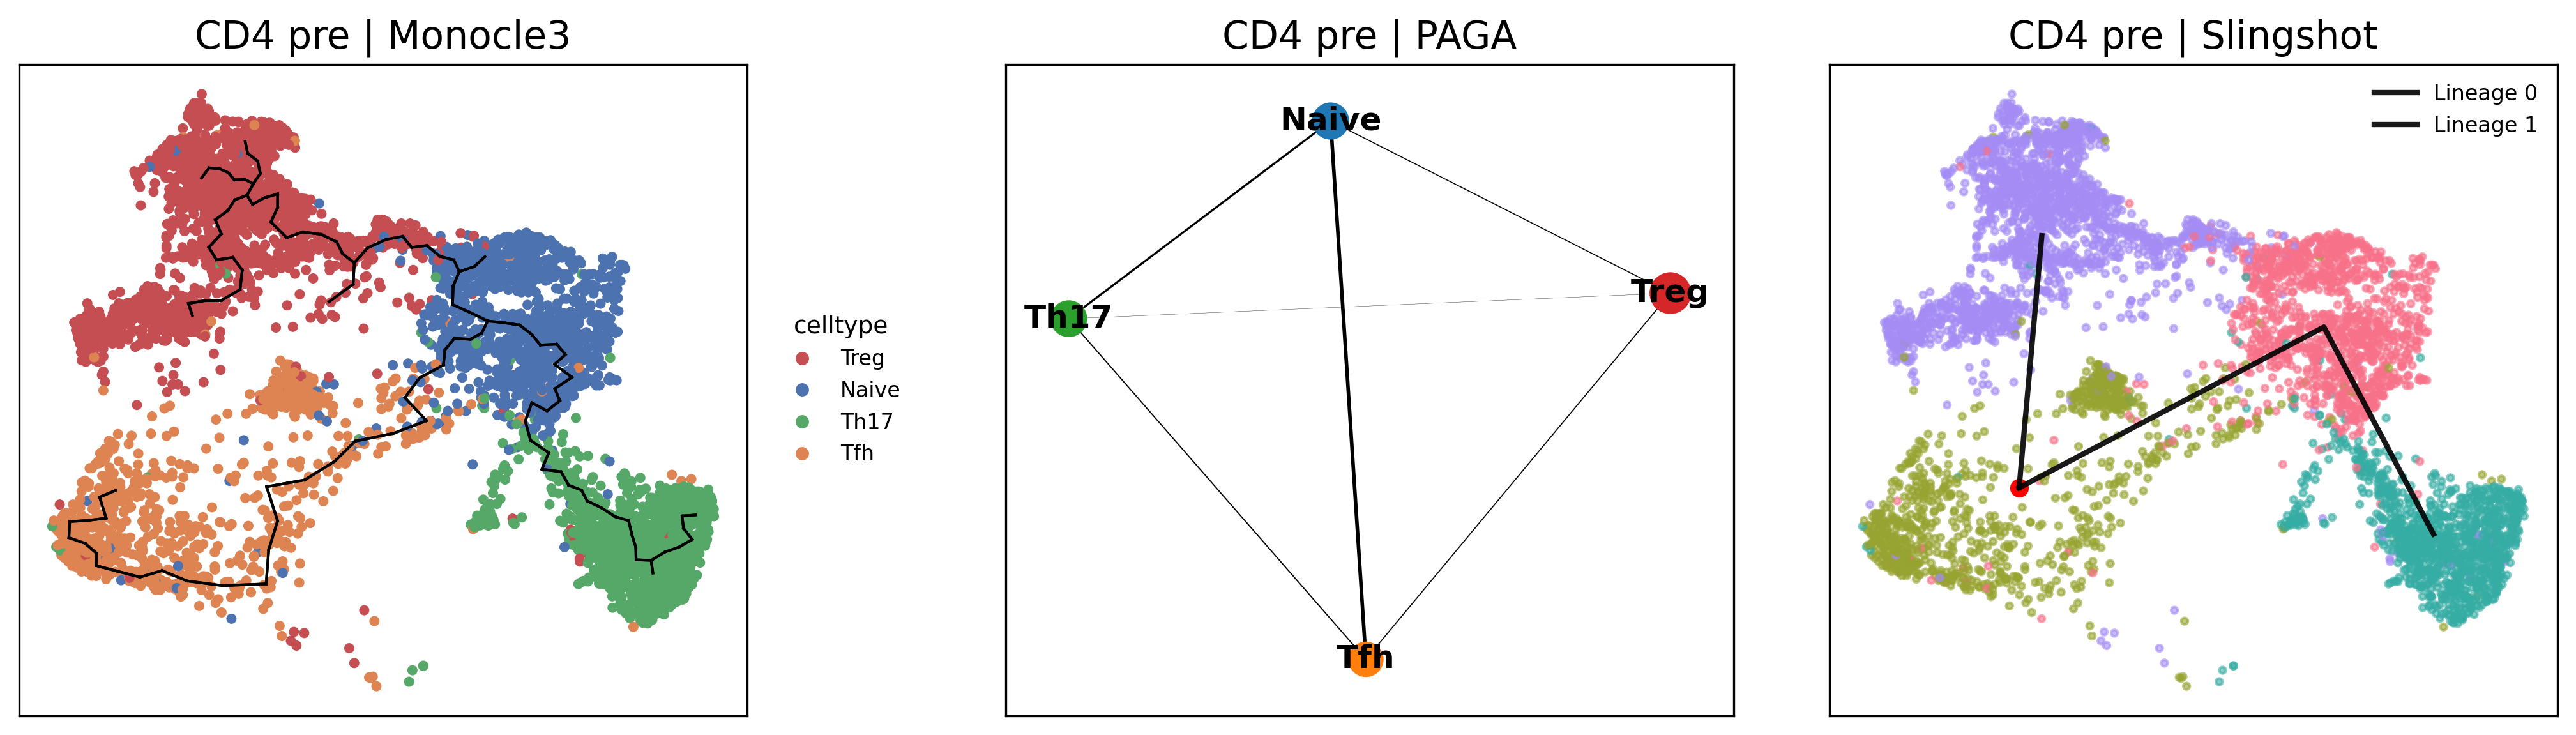

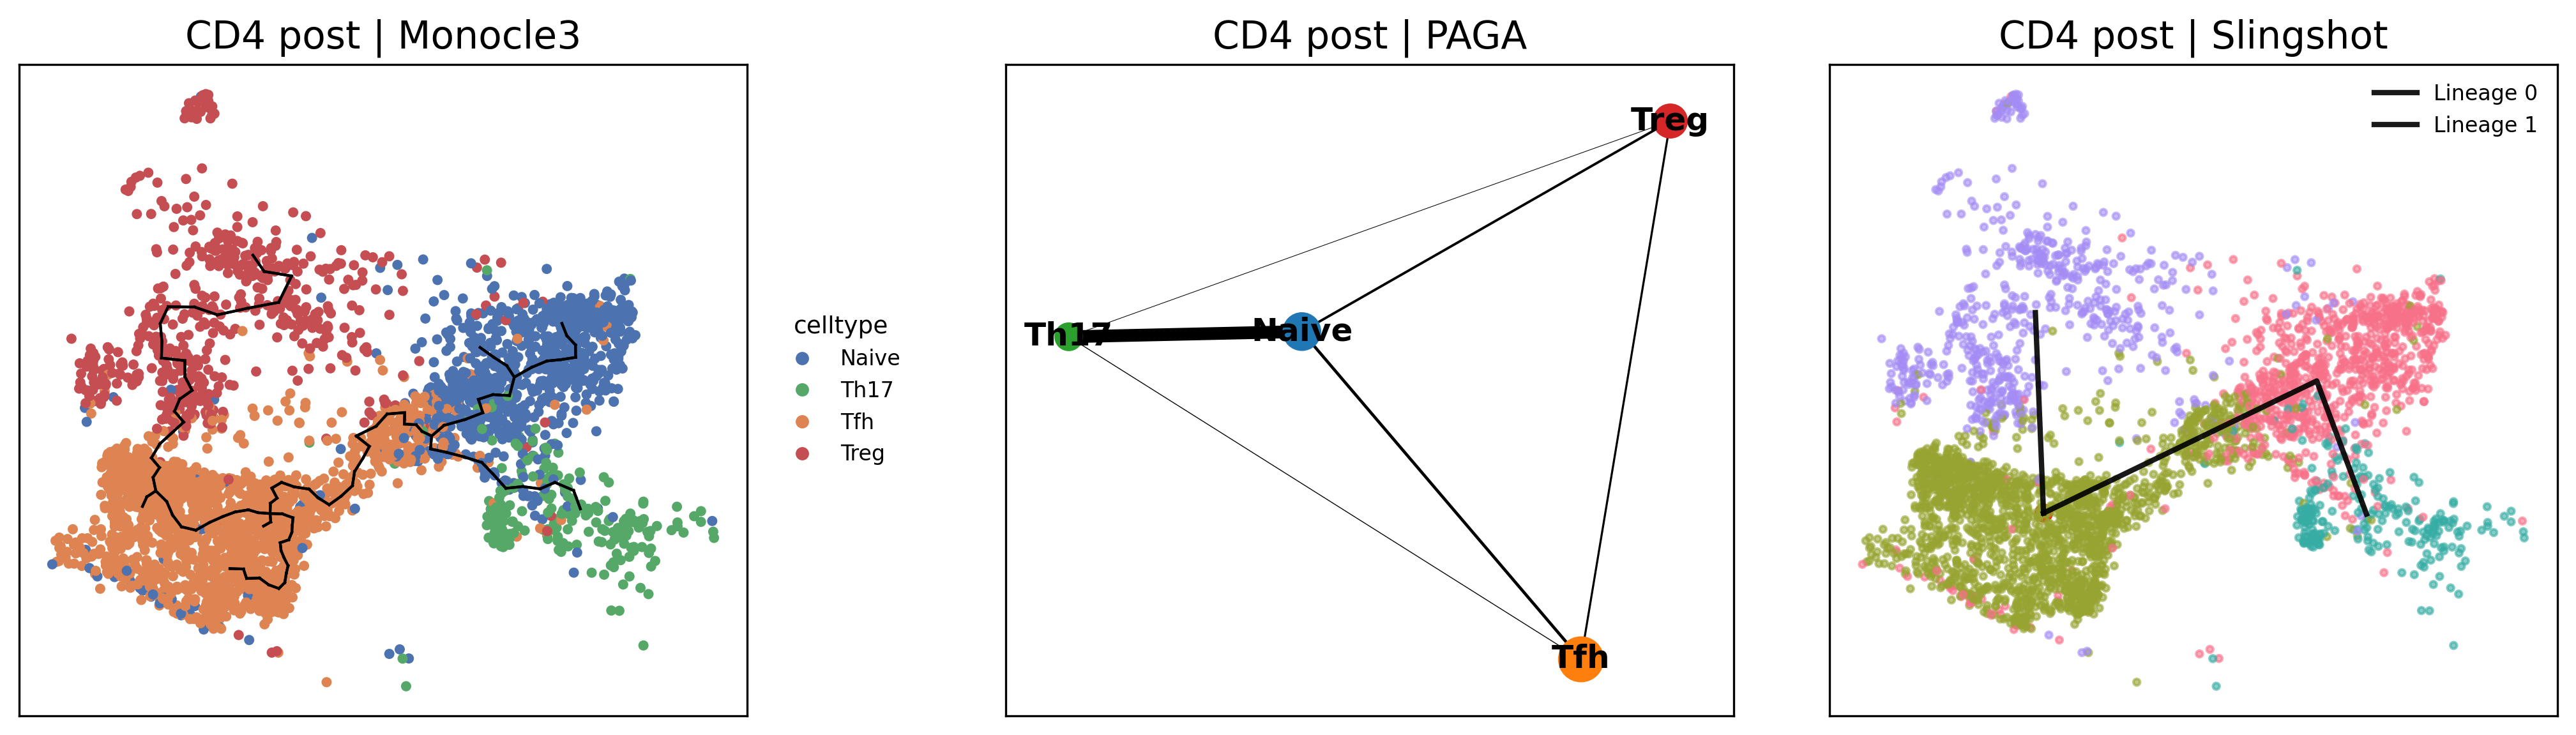

<Figure size 640x480 with 0 Axes>

In [6]:
from IPython.display import display

rows = [
    build_trajectory_row(
        adata_cd8_pre,
        palette_cd8,
        root_celltype="CD8_naive",
        start_node=4,
        row_name="CD8 pre",
        label_prefix="cd8_pre",
        brick_figsize=(3.8, 3.4)
    ),

    build_trajectory_row(
        adata_cd8_post,
        palette_cd8,
        root_celltype="CD8_naive",
        start_node=4,
        row_name="CD8 post",
        label_prefix="cd8_post",
        brick_figsize=(3.8, 3.4)
    ),

    build_trajectory_row(
        adata_cd4_pre,
        palette_cd4,
        root_celltype="Naive",
        start_node=0,
        row_name="CD4 pre",
        label_prefix="cd4_pre",
        brick_figsize=(3.8, 3.4)
    ),

    build_trajectory_row(
        adata_cd4_post,
        palette_cd4,
        root_celltype="Naive",
        start_node=0,
        row_name="CD4 post",
        label_prefix="cd4_post",
        brick_figsize=(3.8, 3.4)
    ),
]

for row in rows:
    display(row)

In [ ]:
from IPython.display import display

rows = [
    build_trajectory_row(
        adata_cd8_pre,
        palette_cd8,
        root_celltype="CD8_naive",
        start_node=4,
        row_name="CD8 pre",
        label_prefix="cd8_pre",
        brick_figsize=(3.8, 3.4)
    ),

    build_trajectory_row(
        adata_cd8_post,
        palette_cd8,
        root_celltype="CD8_naive",
        start_node=4,
        row_name="CD8 post",
        label_prefix="cd8_post",
        brick_figsize=(3.8, 3.4)
    ),

    build_trajectory_row(
        adata_cd4_pre,
        palette_cd4,
        root_celltype="Naive",
        start_node=0,
        row_name="CD4 pre",
        label_prefix="cd4_pre",
        brick_figsize=(3.8, 3.4)
    ),

    build_trajectory_row(
        adata_cd4_post,
        palette_cd4,
        root_celltype="Naive",
        start_node=0,
        row_name="CD4 post",
        label_prefix="cd4_post",
        brick_figsize=(3.8, 3.4)
    ),
]